# SPX Implied Volatility Smile and SVI Calibration

This notebook reconstructs an SPX implied-volatility smile from raw bid/ask quotes, estimates the forward and discount factor from put-call parity, calibrates raw SVI, and performs numerical static-arbitrage diagnostics.

The raw Cboe CSV is intentionally not committed to the repository. Place it at `data/raw/spx_quotedata.csv` before running the notebook.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from src.data import read_cboe_metadata, load_cboe_csv, clean_quotes
from src.forward import estimate_forward_and_discount
from src.smile import build_volatility_smile
from src.svi import calibrate_svi, svi_total_variance
from src.arbitrage import (
    svi_call_prices,
    check_call_monotonicity,
    check_butterfly_arbitrage,
)

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "raw" / "spx_quotedata.csv"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load and clean the option chain

The downloaded Cboe file contains metadata above the table and repeated call/put column names. The loader standardizes the schema and computes bid/ask mid-prices.

In [2]:
metadata = read_cboe_metadata(DATA_PATH)
data = clean_quotes(load_cboe_csv(DATA_PATH))

expiration = data["expiration"].iloc[0]
T = (expiration - metadata["quote_date"]).days / 365.0

print("Quote date:", metadata["quote_date"].date())
print("Displayed SPX level:", metadata["spot_displayed"])
print("Expiration:", expiration.date())
print("Time to maturity:", round(T, 6))
print("Raw strikes after basic cleaning:", len(data))

Quote date: 2026-10-07
Displayed SPX level: 7801.77
Expiration: 2026-11-20
Time to maturity: 0.120548
Raw strikes after basic cleaning: 485


## 2. Recover the forward and discount factor

For European options,

\[
C(K,T)-P(K,T)=D(T)\big(F(T)-K\big).
\]

Therefore a linear regression of \(C-P\) on strike has slope \(-D\) and intercept \(DF\).

In [3]:
forward_result = estimate_forward_and_discount(data, window=500)

F = forward_result["forward"]
D = forward_result["discount_factor"]

print(f"Forward: {F:.4f}")
print(f"Discount factor: {D:.8f}")
print(f"Center strike: {forward_result['center_strike']:.1f}")
print(f"R^2: {forward_result['r_squared']:.10f}")
print(f"RMSE: {forward_result['rmse']:.6f} index points")

Forward: 7833.6895
Discount factor: 0.99465845
Center strike: 7835.0
R^2: 0.9999999198
RMSE: 0.077627 index points


## 3. Construct the market implied-volatility smile

We use OTM puts for strikes below the forward and OTM calls above the forward. Quotes with zero bid, excessive relative spread, or extreme strike ratios are removed.

In [4]:
smile = build_volatility_smile(
    data=data,
    F=F,
    T=T,
    discount_factor=D,
)

print("Retained smile quotes:", len(smile))
print("Strike range:", smile["strike"].min(), "to", smile["strike"].max())
smile.head()

Retained smile quotes: 389
Strike range: 5500.0 to 8650.0


,strike,option_type,bid,ask,mid,relative_spread,log_moneyness,implied_vol,total_variance
0,5500.0,put,2.35,2.55,2.450,0.081633,-0.353686,0.421185,0.021385
1,5525.0,put,2.40,2.60,2.500,0.080000,-0.349150,0.417330,0.020995
2,5550.0,put,2.50,2.70,2.600,0.076923,-0.344636,0.414437,0.020705
3,5575.0,put,2.55,2.75,2.650,0.075472,-0.340141,0.410528,0.020316
4,5600.0,put,2.65,2.80,2.725,0.055046,-0.335667,0.407069,0.019975


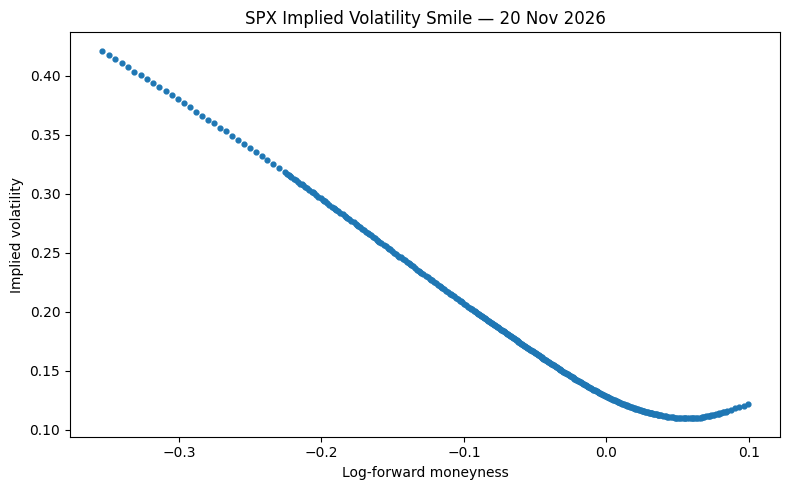

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(smile["log_moneyness"], smile["implied_vol"], s=12)
plt.xlabel("Log-forward moneyness")
plt.ylabel("Implied volatility")
plt.title("SPX Implied Volatility Smile — 20 Nov 2026")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "implied_vol_smile.png", dpi=180)
plt.show()

## 4. Calibrate raw SVI

For one maturity, raw SVI models total implied variance as

\[
w(k)=a+b\left[\rho(k-m)+\sqrt{(k-m)^2+\sigma^2}\right],
\qquad
w(k)=\sigma_{\mathrm{imp}}(k)^2T.
\]

The five parameters are estimated by nonlinear least squares.

In [6]:
svi_result = calibrate_svi(
    smile["log_moneyness"],
    smile["total_variance"],
)

params = svi_result.x
a, b, rho, m, sigma_svi = params

market_k = smile["log_moneyness"].to_numpy()
market_w = smile["total_variance"].to_numpy()
market_iv = smile["implied_vol"].to_numpy()

fitted_w = svi_total_variance(market_k, *params)
fitted_iv = np.sqrt(fitted_w / T)

rmse_w = np.sqrt(np.mean((fitted_w - market_w) ** 2))
rmse_iv = np.sqrt(np.mean((fitted_iv - market_iv) ** 2))

print("Calibration successful:", svi_result.success)
print(f"a = {a:.8f}")
print(f"b = {b:.8f}")
print(f"rho = {rho:.8f}")
print(f"m = {m:.8f}")
print(f"sigma_svi = {sigma_svi:.8f}")
print(f"Total-variance RMSE = {rmse_w:.8e}")
print(f"IV RMSE = {rmse_iv:.8f} ({rmse_iv * 10000:.2f} vol bps)")

Calibration successful: True
a = -0.04319284
b = 0.12808987
rho = 0.19475483
m = 0.12732078
sigma_svi = 0.35547421
Total-variance RMSE = 1.89126001e-05
IV RMSE = 0.00037325 (3.73 vol bps)


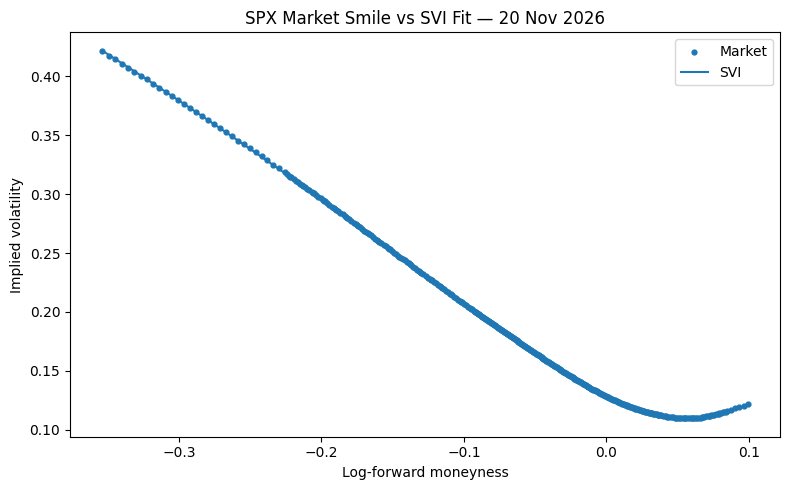

In [7]:
k_grid = np.linspace(market_k.min(), market_k.max(), 400)
w_grid = svi_total_variance(k_grid, *params)
iv_grid = np.sqrt(w_grid / T)

plt.figure(figsize=(8, 5))
plt.scatter(market_k, market_iv, s=12, label="Market")
plt.plot(k_grid, iv_grid, label="SVI")
plt.xlabel("Log-forward moneyness")
plt.ylabel("Implied volatility")
plt.title("SPX Market Smile vs SVI Fit — 20 Nov 2026")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "svi_fit.png", dpi=180)
plt.show()

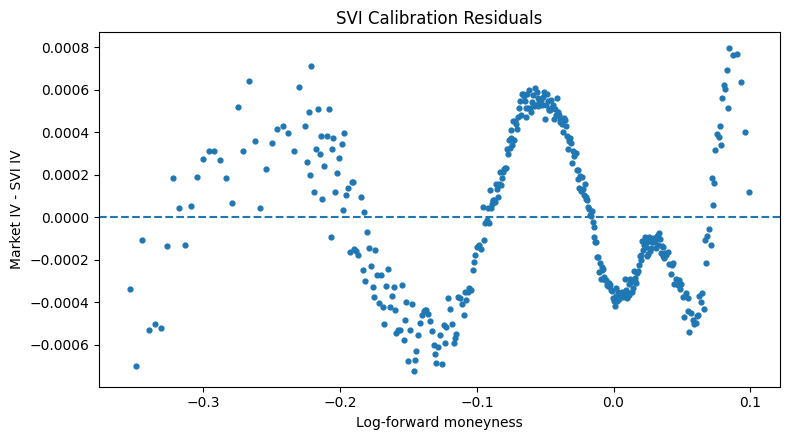

In [8]:
iv_residuals = market_iv - fitted_iv

plt.figure(figsize=(8, 4.5))
plt.scatter(market_k, iv_residuals, s=12)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Log-forward moneyness")
plt.ylabel("Market IV - SVI IV")
plt.title("SVI Calibration Residuals")
plt.tight_layout()
plt.show()

## 5. Numerical static-arbitrage diagnostics

The fitted SVI smile is converted back to call prices on a dense, equally spaced strike grid over the observed calibration range. We test

\[
\frac{\partial C}{\partial K}\le 0
\]

and

\[
\frac{\partial^2 C}{\partial K^2}\ge 0.
\]

These are numerical diagnostics over the tested range; they are not a proof of global arbitrage-freeness for all strikes.

In [9]:
strike_grid = np.linspace(
    smile["strike"].min(),
    smile["strike"].max(),
    1000,
)

call_prices = svi_call_prices(
    strikes=strike_grid,
    F=F,
    T=T,
    discount_factor=D,
    svi_params=params,
)

first_diff, monotonicity_violations = check_call_monotonicity(call_prices)
second_diff, butterfly_violations = check_butterfly_arbitrage(call_prices)

print("Monotonicity violations:", monotonicity_violations.sum())
print("Butterfly violations:", butterfly_violations.sum())
print("Minimum second difference:", second_diff.min())

Monotonicity violations: 0
Butterfly violations: 0
Minimum second difference: 2.9273661311890464e-05


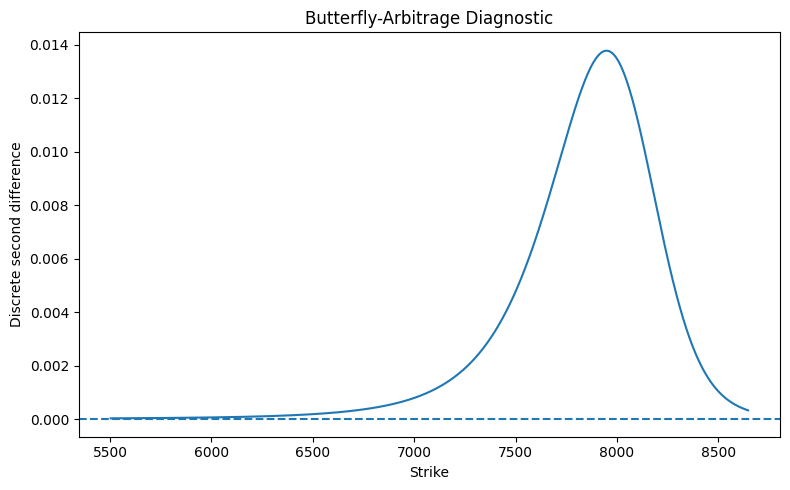

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(strike_grid[1:-1], second_diff)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Strike")
plt.ylabel("Discrete second difference")
plt.title("Butterfly-Arbitrage Diagnostic")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "arbitrage_diagnostic.png", dpi=180)
plt.show()

## Current result

The current version demonstrates a complete single-maturity calibration workflow: raw option quotes → forward/discount estimation → implied-volatility inversion → SVI calibration → numerical static-arbitrage checks.

Natural extensions are multiple expiries, a full volatility surface, calendar-arbitrage diagnostics, SSVI, Dupire local volatility, and stochastic-volatility calibration.